# Data Challenge 12 — Intro to Logistic Regression

**Hook (Attention Grabber)**  
> “If an app told a restaurant it has an 80% chance of getting an **A** on inspection, would you trust it?”

**Learning Goals**
- Show why **linear regression** is a bad fit for a **binary (0/1)** target.
- Fit a **one-feature logistic regression** and interpret probabilities.
- Extend to a **two-feature logistic model with standardized inputs**.
- Communicate results using **AWES** and discuss **ethics & people impact**.

**Data:** June 1, 2025 - Nov 4, 2025 Restaurant Health Inspection

[Restaurant Health Inspection](https://data.cityofnewyork.us/Health/DOHMH-New-York-City-Restaurant-Inspection-Results/43nn-pn8j/about_data)


## Instructor Guidance

**Hint: Use the Lecture Deck, Canvas Reading, and Docs to help you with the code**

Use this guide live; students implement below.

**Docs (quick links):**
- Train/Test Split — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- LinearRegression — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
- LogisticRegression — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- StandardScaler — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
- accuracy_score — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html
- corr — pandas: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html

### Pseudocode Plan (Linear vs Logistic + Scaling)
1) **Load CSV** → preview shape/columns; keep needed fields.  
2) **Engineer binary Y**: `is_A = 1 if grade == 'A' else 0`.  
3) **Pick numeric X**:  
   - **X1:** `score` (inspection score; lower is better)  
   - **X2:** `critical_num = 1 if critical_flag == 'Critical' else 0` (for extension)  
4) **Split** → `X_train, X_test, y_train, y_test` (70/30, stratify by Y, fixed random_state).  
5) **Model A (Incorrect)** → **LinearRegression** on Y~X1:  
   - Report **MSE**, **R²**, count predictions **<0 or >1**,  
6) **Model B (Correct)** → **LogisticRegression** on Y~X1:  
   - Report **Accuracy**
7) **Visual (OPTIONAL)** → scatter Y vs X1 with **linear line** vs **logistic sigmoid** curve  
8) **Extension** → scale X1+X2 with **StandardScaler**; fit **LogisticRegression**:  
   - Compare **Accuracy** to one-feature logistic  
9) **Interpret** → 2–3 sentences on why linear fails and how logistic fixes it  


## You Do — Student Section
Work in pairs. Comment your choices briefly. Keep code simple—only coerce the columns you use.

## Step 1 — Imports and Plot Defaults

In [345]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import mean_squared_error,accuracy_score
import seaborn as sns
from sklearn import preprocessing


### Step 2 — Load CSV & Preview
- Point to your New York City Restaurant Inspection Data 

In [346]:
df = pd.read_csv("../data/DOHMH_New_York_City_Restaurant_Inspection_Results_20251104 copy.csv")

display(df.shape)
display(df.info())

(291278, 27)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291278 entries, 0 to 291277
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CAMIS                  291278 non-null  int64  
 1   DBA                    291274 non-null  object 
 2   BORO                   291278 non-null  object 
 3   BUILDING               290428 non-null  object 
 4   STREET                 291267 non-null  object 
 5   ZIPCODE                288169 non-null  float64
 6   PHONE                  291271 non-null  object 
 7   CUISINE DESCRIPTION    287380 non-null  object 
 8   INSPECTION DATE        291278 non-null  object 
 9   ACTION                 287380 non-null  object 
 10  VIOLATION CODE         285078 non-null  object 
 11  VIOLATION DESCRIPTION  285078 non-null  object 
 12  CRITICAL FLAG          291278 non-null  object 
 13  SCORE                  274939 non-null  float64
 14  GRADE                  142210 non-nu

None

## Step 3 — Clean and Engineer Features
- Make sure `SCORE` is numeric and do any other data type clean-up 
- Engineer binary target variable (Y) based on instructor guidance above `is_A`
- Engineer binary predictor (X) based on instructor guidance above `critical_num`


In [347]:
#turning SCORE column to numeric
df['SCORE'] = pd.to_numeric(df['SCORE'])

# creating new df where score isn't NA
df_wscore = df[df['SCORE'].notna()]

# boolean to determine if grade is A
df_wscore['IS_A'] = (df['GRADE'] == 'A').astype(int)
# just checking if correct
# has a lot of NaN values for 'GRADE', but will address later when using 'GRADE' column in our model
df_wscore[['GRADE','IS_A']]


/var/folders/3y/ldxff8k17wjcyzkq19xw1srm0000gn/T/ipykernel_16290/3347083450.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_wscore['IS_A'] = (df['GRADE'] == 'A').astype(int)


,GRADE,IS_A
18,A,1
19,NaN,0
36,A,1
37,P,0
54,A,1
...,...,...
291273,NaN,0
291274,NaN,0
291275,B,0
291276,N,0


In [348]:
df_wscore['CRITICAL_NUM'] = (df_wscore['CRITICAL FLAG'] == 'Critical').astype(int)

df_wscore['CRITICAL_NUM'].value_counts()

/var/folders/3y/ldxff8k17wjcyzkq19xw1srm0000gn/T/ipykernel_16290/2106483680.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_wscore['CRITICAL_NUM'] = (df_wscore['CRITICAL FLAG'] == 'Critical').astype(int)


CRITICAL_NUM
1    153985
0    120954
Name: count, dtype: int64

## Step 4 — Split Data (70/30 Stratify by Target)

In [349]:
# creating df for the test
testdf = df_wscore[['IS_A','SCORE','CRITICAL_NUM']]

# keeping only values that are not NA
testdf = testdf[testdf['SCORE'].notna()]

np.random.seed(9001)
X_train, X_test, y_train, y_test = train_test_split(testdf[['SCORE']], testdf['IS_A'], test_size=0.3, random_state=9001, stratify=testdf['IS_A'])

## Step 5 — Model A: Linear Regression on a Binary Target (Incorrect)

- Fit `is_A (Y var) ~ SCORE (X pred)` using **LinearRegression**  
- Report **MSE**, **R²**, and how many predictions fall outside [0, 1]  
- Estimate accuracy by thresholding predictions at 0.5 (done for you but understand the code) 

💡 Hint:  
`accuracy_score(y_test, (y_pred >= 0.5).astype(int))`

In [350]:
# Creating a Linear Regression Model and fitting to our train data
model_skl = LinearRegression()
model_skl.fit(X_train, y_train)

# creating predictions to use for our next step
predictions = model_skl.predict(X_test)

# for loop that counts if number in predictions array is greater than 1 or less than 0
count = 0
for i in range(len(predictions)):
    if (predictions[i] > 1) | (predictions[i] < 0):
        count = count + 1

print("There are",count,'values in our prediction that are greater than 1 or less than 0.')

There are 8617 values in our prediction that are greater than 1 or less than 0.


In [351]:
# COEFFICIENTS, R SQUARED OF LINEAR REGRESSION (one X)
print("Our Linear Model's Coefficient is:", model_skl.coef_)
r_squared = model_skl.score(X_test,y_test)
print("The Model's R Squared is:",round(r_squared,4))
mse = mean_squared_error(y_test,predictions)
print("The Model's MSE is:",round(mse,4))

Our Linear Model's Coefficient is: [-0.01477515]
The Model's R Squared is: 0.3426
The Model's MSE is: 0.1496


In [352]:
# Estimated Accuracy
print('The Accuracy Score is:',round(accuracy_score(y_test, (predictions >= 0.5).astype(int)),5))

The Accuracy Score is: 0.95218


## Step 6 — Model B: Logistic Regression (One Feature)

- Fit `is_A ~ score` using **LogisticRegression**  
- Compute predictions with `.predict()`  
- Evaluate accuracy with `accuracy_score()`

In [353]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

logistic_pred = log_reg.predict(X_test)

In [354]:
print('The Accuracy Score is:',round(accuracy_score(y_test, (logistic_pred >= 0.5).astype(int)),5))

# accuracy score is just as good

The Accuracy Score is: 0.95218


In [355]:
# for loop that counts if number in predictions array is greater than 1 or less than 0
count = 0
for i in range(len(logistic_pred)):
    if (logistic_pred[i] > 1) | (logistic_pred[i] < 0):
        count = count + 1

print("There are",count,'values in our prediction that are greater than 1 or less than 0.')

# 0 VALUES ABOVE 1 OR BELOW 0 WITH SAME ACCURACY SCORE ???

There are 0 values in our prediction that are greater than 1 or less than 0.


## Step 7 (OPTIONAL) — Visual Comparison: Linear vs Logistic


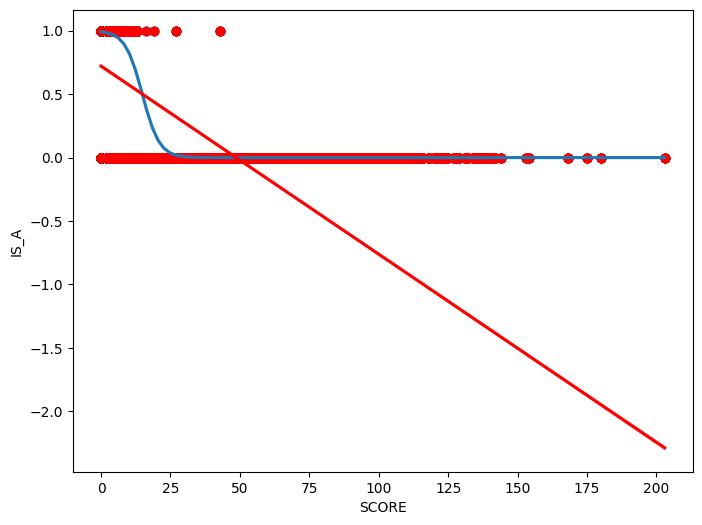

In [356]:
fig, axs = plt.subplots(figsize=(8,6))

#SIGMOID CURVE
#define the predictor variable and the response variable
x = testdf['SCORE']
y = testdf['IS_A']

#plot logistic regression curve
sns.regplot(x=x, y=y, data=testdf, logistic=True, ci=None,ax=axs)

#plotting lineplot with the same data
sns.regplot(x=x, y=y, data=testdf, ax=axs,color='red')

plt.show()

## Step 8 — Logistic Regression with Two **Scaled** Features

- Use `SCORE` and `critical_num` as your two X predictors that need to be scaled
- Look at documentation above to see how you would fit a StandardScalar() object 


In [357]:
scaled = preprocessing.StandardScaler()
scaleddf = scaled.fit_transform(testdf[['CRITICAL_NUM','SCORE']])

standard_df = pd.DataFrame(scaleddf, columns=['CRITICAL_NUM', 'SCORE'])

In [358]:
scaledx_train, scaledx_test, scaledy_train, scaledy_test = train_test_split(standard_df[['CRITICAL_NUM','SCORE']], testdf['IS_A'], test_size=0.3, random_state=9001, stratify=testdf['IS_A'])

scaledlog_reg = LogisticRegression()
scaledlog_reg.fit(scaledx_train, scaledy_train)

scaled_pred = scaledlog_reg.predict(scaledx_test)

# Estimated Accuracy
print('The Accuracy Score is:',round(accuracy_score(scaledy_test, (scaled_pred >= 0.5).astype(int)),5))


The Accuracy Score is: 0.94952


In [359]:
display(testdf)
display(standard_df)

,IS_A,SCORE,CRITICAL_NUM
18,1,13.0,1
19,0,0.0,0
36,1,13.0,0
37,0,0.0,0
54,1,0.0,0
...,...,...,...
291273,0,0.0,0
291274,0,40.0,1
291275,0,27.0,1
291276,0,31.0,0


,CRITICAL_NUM,SCORE
0,0.886280,-0.640205
1,-1.128312,-1.332684
2,-1.128312,-0.640205
3,-1.128312,-1.332684
4,-1.128312,-1.332684
...,...,...
274934,-1.128312,-1.332684
274935,0.886280,0.798019
274936,0.886280,0.105541
274937,-1.128312,0.318611


# We Share — Reflection & Wrap-Up

Write **two short paragraphs** (4–6 sentences each). Be specific and use evidence from your notebook.

1️⃣ **How do you know Linear Regression was a poor model choice for this task?**  
Describe what you observed in your results or plots that showed it didn’t work well for a binary outcome.  
Consider: Were predictions outside 0–1? Did the fit look wrong? What happened when you used 0.5 as a cutoff?  
Connect this to the idea that classification models should output probabilities between 0 and 1.

After I predicted the values for both our Linear and Logistic Regression, it made me certain that a Logistic Regression was the correct model choice for this task. I was able to observe that 8617 of the Linear model's predictions led to many values being above the [0,1] range that a percentile must fall within, as values of less than 0 and above 1 are incorrect when plotting for probabilities. In contrast, the Logistic Regression had no values that fell below 0 or above 1 due to the logit function, making it more valid for plotting probabilities. This also makes sense as Linear Regression is continuous while Logistic Regression is categorical/probabilistic.

2️⃣ **When should we scale features in logistic regression (and when not to)?**  
Explain what scaling does, and why it might (or might not) matter for different kinds of features.  
Use this project to reason through whether `score` and `critical_num` needed scaling.  
Hint: Think about what “continuous” vs “binary” means for scaling decisions.

When we use StandardScaler, we standardize the values on a standard normal distribution, meaning we will have a mean of 0 and standard deviation of one. This allows for us to compare different features on the same scale, or "comparing apples to apples." When I used standard scaler on our the features 'SCORE' and 'CRITICAL_NUM', it put both features on the same standardized scale, with a range of -3 to 3 for most data, and outliers/least probabilistic values outside of that range. The features needed scaling as the predictive model would prioritize larger values and in our data the 'SCORE' feature has values far larger than the [0,1] range of the binomials in the 'CRITICAL_NUM' feature. We should scale features when we have continous features in our model alongisde binary ones to avoid biases.